In [694]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [695]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.


#========================================#
#TODO 1 - Loading the taxi dataset into a dataframe called taxi

taxi_df = pd.read_csv(TAXI_URL)

#TODO 2 - Inspecting the loaded dataset one by one ber code block



In [696]:
#TODO 2 - Inspecting the loaded dataset one by one per code block
#Inspection block 1 - info.
taxi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


In [697]:
#Inspection block 2 - shape.
taxi_df.shape

(41202, 13)

In [698]:
#Inspection block 3 - head.
taxi_df.head()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [699]:
#Inspection block 4 - descrbe.
taxi_df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


In [700]:
#Inspection block 5 - checking for missing values.
taxi_df.isna().sum()

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


In [701]:
#Inspection block 6 - dropping possible duplicates

taxi_df = taxi_df.drop_duplicates()

In [702]:
#Inspection block 7 - impossible values checker

(taxi_df["tip_amount"] < 0).sum()
(taxi_df["trip_distance"] <= 0).sum()
(taxi_df["fare_amount"] <= 0).sum()

#No impossible value found

np.int64(0)

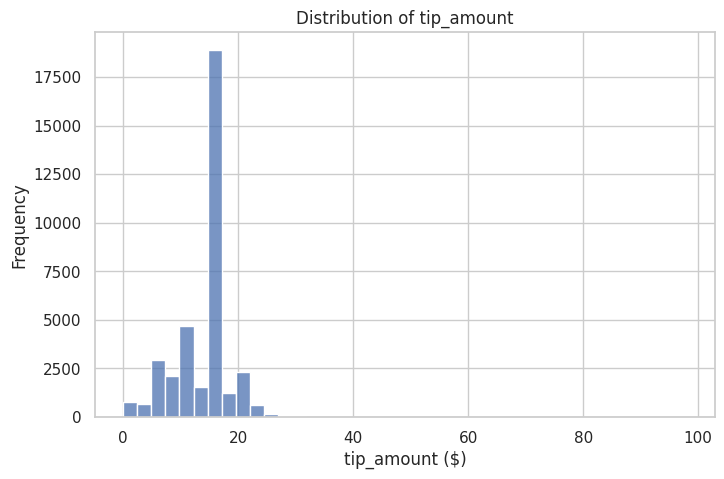

In [703]:
#TODO 3 - Visualising the distribution of the target `tip_amount`

plt.figure(figsize=(8,5)) # Blank canvas creation, if i didnt specify, matplotlib wouldve just used a default size

sns.histplot(taxi_df["tip_amount"], bins=40,) # Actual plotting call, pulls out ``tip_amount from the dataset and builds a histogram of it, with 40 buckets across range

plt.title("Distribution of tip_amount")
plt.xlabel("tip_amount ($)") # Handles plot labelling
plt.ylabel("Frequency")

plt.show() # Displays the visualisation

#The overall shape and features of this histogram is that its right skewed, roughly unimodal and has some subpeaks within the main cluster.
#Its tail appears long and it has an anomaly which is one dominant spike at 16.19 dollars.

#========================================#


Student Reasoning

This dataset is one with multiple taxi trip that have both numerical and catgorical data. There were no missing or impossible values so far during the dataset inspection and all duplicate values were removed before visualisation. The distribution in question is right skewed, indicating the precence of outliers that might affect the perfomance of the model.

In [704]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

In [705]:
#========================================#

# TODO 4 - Handling missing or invalid rows in the dataset
# Duplicate rows drop already done in code block 8

#Dropping impossible values (None exist actually)
taxi_df = taxi_df.dropna()


In [706]:
# Removing impoossible trips/ rows

taxi_df = taxi_df[taxi_df["trip_distance"]> 0]
taxi_df = taxi_df[taxi_df["fare_amount"]> 0]
taxi_df = taxi_df[taxi_df["tip_amount"] >= 0]



In [707]:
# TODO 5 - Feature Engineering (creating a new justified feature, in this case - fare per mile and total surcharges)


# Fare per mile feature
taxi_df["fare_per_mile"] = taxi_df["fare_amount"] / taxi_df["trip_distance"]



In [708]:
#Total Surcharge feature

taxi_df["total_surcharge"] = (taxi_df["mta_tax"] +
                              taxi_df["tolls_amount"] +
                              taxi_df["improvement_surcharge"])

In [709]:
# TODO 6 - Determining which columns are categorical versus those that are numeric
# Encoding the categorical data
categorical_columns = ["VendorID",
                       "RatecodeID",
                       "store_and_fwd_flag",
                       "payment_type",
                       "PULocationID",
                       "DOLocationID"]

In [710]:
#TODO 7 - Scaling the numeric features

taxi_df = pd.get_dummies(taxi_df, columns = categorical_columns, drop_first = True)


Student Reasoning

The missing values were removed using dropna() and also the zero or negative distances and fares or negative tips were also removed because they were invalid observations that will diminish the accuracy of the model if kept. I created two new features, i.e. the fare per mile feature and the total surcharge. The were created to provide metadata or additional information about trip costs without relying on the target value alone, there by allowing and helping the model learn very useful patterns

In [711]:
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

In [712]:
# TODO 8 - Separating the features
x = taxi_df.drop("tip_amount", axis = 1)
y = taxi_df["tip_amount"]


In [713]:
#TODO 9 - Splitting into train, validation and test sets
#Splitting test set first (20)
x_temp, x_test, y_temp, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

In [714]:
# Splitting the remaining data
x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE
)

In [715]:
# checking the sizes again to make sure
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(21594, 270)
(7198, 270)
(7199, 270)


In [716]:
# TODO 10 - fitting the scaler to the training set only

#scaler creation
scaler = StandardScaler()

In [717]:
# Fitting to training set ONLY first
x_train_scaled = scaler.fit_transform(x_train)

In [718]:
# Then transforming the others
x_val_scaled = scaler.transform(x_val)

x_test_scaled = scaler.transform(x_test)

Student Reasoning

The dataset was split into 3 different sets, namely Training(60%), testing(20%) and validation(also 20%). The training set is used to learn the model, the validation for model comparison, and finally the test set is used for final evaluation. The scaler was fitted on the training data only in order to prevent data leakage concerns, making sure that the data from the training and validation sets wont affect or influence the model training.

In [719]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

# TODO: Predict on train, validation, and test sets.

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

In [720]:
# TODO 11 - Initialising and training a simple regression model

lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

LinearRegression()

In [721]:
# Prediction
y_train_pred_lr = lr.predict(x_train_scaled)
y_val_pred_lr = lr.predict(x_val_scaled)
y_test_pred_lr = lr.predict(x_test_scaled)

In [722]:
# Evaluation
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

In [723]:
# Execution
print("Linear Regression:")
print("Train:", evaluate(y_train, y_train_pred_lr))
print("Val:", evaluate(y_val, y_val_pred_lr))
print("Test:", evaluate(y_test, y_test_pred_lr))

Linear Regression:
Train: (np.float64(5.004863829361324), 0.0639227311238163)
Val: (np.float64(5.318700580377634), 0.047117065280430914)
Test: (np.float64(5.282024520679032), 0.03481849715898222)


In [724]:
# Training a stronger model (Random Forest Model)
# Training
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [725]:
# Prediction
rf_train_pred = rf.predict(x_train_scaled)
rf_val_pred = rf.predict(x_val_scaled)
rf_test_pred = rf.predict(x_test_scaled)

In [726]:
# Evaluation
print("Random Forest")

print("Train:", evaluate(y_train, rf_train_pred))
print("Validation:", evaluate(y_val, rf_val_pred))
print("Test:", evaluate(y_test, rf_test_pred))

Random Forest
Train: (np.float64(2.8940374080664393), 0.6870064063555077)
Validation: (np.float64(6.057107410229647), -0.23583080087382124)
Test: (np.float64(6.141981783793193), -0.30504417465470923)


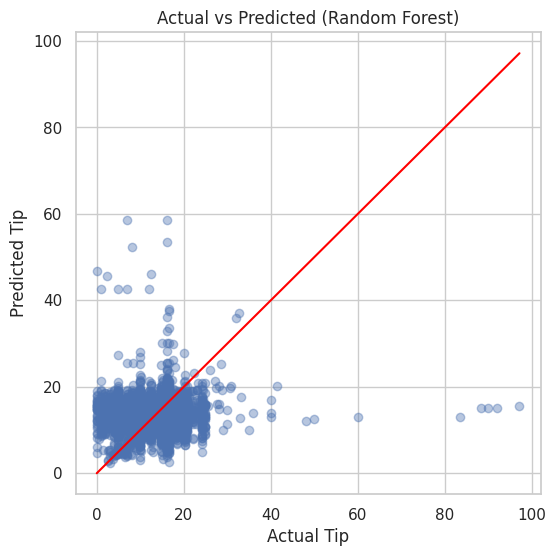

In [727]:
# Plotting the actual trip vs predicted one for test set.

plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_test_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

Student Reasoning

The Best model between the two that were trained was the Random Forest Model, performing better on the validation set compared to its counterpart, the Linear Regression Model. The hyperparameter used was n_estimators = 100 with a default tree depth.

**Overfitting?**

Linear Regression showed same results across the train, validation and test sets indicating
underfiting.
Linear Regression:

Train: (np.float64(5.004863829361324), 0.0639227311238163)

Val: (np.float64(5.318700580377634), 0.047117065280430914)

Test: (np.float64(5.282024520679032), 0.03481849715898222)


However Random Forest achieved a lower training RMSE compared to the validation RMSE and test RMSE, indicating mild overfitting.
Random Forest

Train: (np.float64(2.8940374080664393), 0.6870064063555077)

Validation: (np.float64(6.057107410229647), -0.23583080087382124)

Test: (np.float64(6.141981783793193), -0.30504417465470923)


**Reducing Overfitting**
To reduce overfitting, its recommended to tune the hyperparameters of Random forest like reducing the max_depth, or even reducing the n_estiman=tors. Another way would also to use cross-validation, for more generalisable models


PART TWO

In [728]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`

# TODO: Inspect shape, head, info, describe, and missing values.

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?

In [729]:
#Loading the csv file
obesity = pd.read_csv(OBESITY_URL)

In [730]:
#Inspections, Head, shape, info, describe, missing value check

In [731]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [732]:
obesity.shape

(2111, 17)

In [733]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [734]:
obesity.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [735]:
obesity.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


Student Reasoning

The dataset contains 2111 rows and 23 features after the pre-processing work was donei.e. before the encoding exoansion. It contains both numerical and categorical data that descrive lifestyle and physical attributes of individuals

Categorical columns: Gender, Family history of overweight, food consumption habits(FAVC, CAEC), smoking status, transportation mode, and alcohol consumptiom

Numerical columns: Age, Height, Weight, FCVC, NCP,CH20,FAF, TUE

The target variable - NOneyesdad, has 7 obesity classes, with iits distribution not balanced perfectly. This imbalance matters in the sense that it can create a bias towards the majority classes, making accuracy very misleading.


In [736]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

In [737]:
#Checking the existence of the target to be sure
"NObeyesdad" in obesity.columns

True

In [738]:
#Separating the x and y before encoding to avoid a key error again(it happened)
x = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

In [739]:
#Encoding the features only
binary_cols = ["family_history_with_overweight",
               "FAVC",
               "SMOKE",
               "SCC"
              ]

for col in binary_cols:
    x[col] = x[col].map({"yes": 1, "no": 0})

In [740]:
#Then the categorical data (OneHotEncoder)
x = pd.get_dummies(x, drop_first=True)

Student Reasoning

Categorical variables were encoded based on their types, using different stratgies. Binary ones were mapped to 0/1 values, ensuring simplicity, while the multiclass categorical ones were one-hot-encoded to avoid the introduction of false ordinal relationships between the  categories.

Didnt engineer any feature

StandardScaler (imported) was used to normalise the feature ranges due to difference in scales, to avoid inconsistency.

In [741]:
# TODO: Separate X (features) and y (encoded NObeyesdad).Done at the top

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

# TODO: Fit the scaler on the training set only, then transform train / val / test.

In [742]:
# Training set, validation set,Test set all split, using stratify
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

In [743]:
# Scaling to Training set Only
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

Student Reasoning

Another 60/20/20 split was used her for training, validation and testing respectively allowing the model to learn from majority of the data while providing different datasets for both tuning/validation and testing.

Stratify = y was used because it was crucial to curb the imbalance of the target variable across the 7 classes. It was used to ensure that each of the splits kept the same proportional representaion of all the obesity categories, and without this some of the classes will be missing entirely when it came to test sets which wouldve led to unreliable evaluation results

In [744]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

# TODO: Predict on train, validation, and test.

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

In [745]:
# Model Training
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [746]:
# Predictions
train_pred = model.predict(x_train)
val_pred = model.predict(x_val)
test_pred = model.predict(x_test)


In [747]:
# Evaluations
def evaluate(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro")
    )

print("Train:", evaluate(y_train, train_pred))
print("Val:", evaluate(y_val, val_pred))
print("Test:", evaluate(y_test, test_pred))

Train: (1.0, 1.0)
Val: (0.9407582938388626, 0.939251266047356)
Test: (0.9456264775413712, 0.9454341080607929)


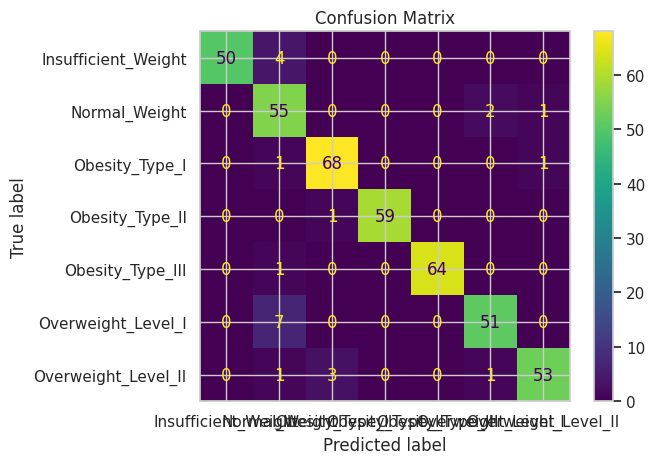

In [748]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title("Confusion Matrix")
plt.show()

Student Reasoning

I chose a Random Forest classifier because of its ability to handle non-linear relationships, and multiclass classification effectively without too much preprocessing

Train: (1.0, 1.0)

Higher(indicates model fits training data well)

Val: (0.9407582938388626, 0.939251266047356)

Lower than training

Test: (0.9456264775413712, 0.9454341080607929)

Similar to validation
This indicates mild overfitting whiere training learnt specific patterns are learn but not fully generalised. However if the validation and test scores are relatively close, generalisation is possible.


The hardest to tell apart classes from the confusion matrix were Overweight Level I VS Overweight Level II and Obesity Type I vs Obesity Type II. This occurs due to the categories having similar feature distributions, rendering them harder to separate

PART THREE


In [749]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

In [750]:
# Preparing the data for clustering
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [751]:
# Elbow method
inertia = []

K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertia.append(km.inertia_)

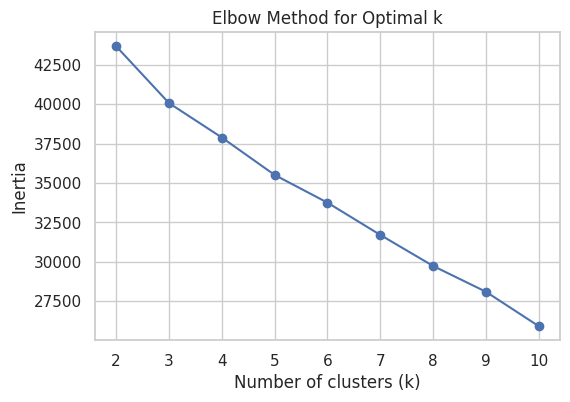

In [752]:
# Plotting the elbow curve

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [753]:
# Fitting the final K-means model

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)

In [754]:
# Adding clusters to the dataset

obesity["Cluster"] = clusters

In [755]:
# Comparing the clusters to real labels

pd.crosstab(obesity["Cluster"], obesity["NObeyesdad"])

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,1,18,14,2,0,16,19
1,94,101,169,224,323,182,134
2,52,63,163,69,1,47,123
3,125,105,5,2,0,45,14


In [756]:
# 2D visualisation

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

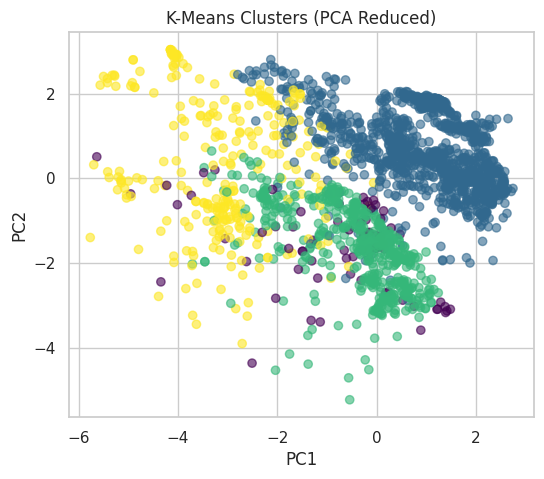

In [757]:
# 2D visualisation continued

plt.figure(figsize=(6,5))
plt.scatter(x_pca[:,0], x_pca[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [758]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

In [759]:
# Crosstab of cluster label vs the real NObeyesdad category
pd.crosstab(obesity["Cluster"], obesity["NObeyesdad"])

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,1,18,14,2,0,16,19
1,94,101,169,224,323,182,134
2,52,63,163,69,1,47,123
3,125,105,5,2,0,45,14


TODO QUESTION

The crosstab between K-means cluster labels and the true obesity levels show that the clusters would only partially align with specific classes.

However, there is still a significant overlap between clusters and multiple obesity levels, which is expected because K-means is an unsupervised learning method and does not untilise label information during training, so it can not separate the defined obesity categories.

The clusters capture the genral structure in the datatset but they do not accurately correspond to the true obesity labels.

Student Reasoning

K was chosen using the elbow method by plotting inertia against many different k values. The elbow point, which is where the rate of decrease slows significantly, shoes an suitable balance between simplicity and compactness.

The crosstab between cluster labels and true obesity classes show partial alignment. They agree with some specific obesity categories but others still overlap

In a public health setting, such clusters would be useful for identifying some hidden population groups with similar lifestyle and health characteristice, aiding in interventions even when labelled data, which is hard to come by, is unavailable, or expensive to collect.

REFLECTION QUESTIONS

Supervised Vs Unsupervised
Classifier learnt  explicit mappings between input features and known obesity levels
k-means identified natural groupings in the data without labels. Supervised learning is goal-driven while unsupervised forcuses on pattern and structure discovery.

Regression vs Classification
Regression predicts a continuous value and is evaluates using RMSE AND R^2, while classification predicts discrete categories, evaluated using accuracy and f1-scores. Regression errors are continuos or numerical whicle classification errors are categorical.

Overfitting
The largest observed overfitting in this lab was in the Random forest regression model where the training performance was highly better than the validation and test performances. The most effectiveway to reduce this would be to control the complexity of the models through thier hyperparameters, an increase or decrease in the values like minimum samples per leaf or tree depth would work.